# Debugging Your Own Gradient Descent

**Sessions 8–10 · companion for HW 2**

HW 2 asks you to write `mse_gradient`, `gradient_descent`, `sigmoid` and
`logistic_gradient` yourself, and the tests say two of them "must pass the
gradient check". This notebook does not implement any of them — that is the
assignment. It teaches the three skills you need to *debug* your own versions:

1. checking a gradient numerically, so you find a sign error in seconds rather
   than by staring;
2. reading a loss history, so you can tell a wrong gradient from a wrong
   learning rate;
3. seeing where a naive sigmoid overflows, so "numerically stable" means
   something concrete.

Run every cell. The outputs below are real runs.

In [1]:
import numpy as np

rng = np.random.default_rng(0)

# A small regression problem whose answer we know: y = 2 - 3*x1 + 0.5*x2 + noise
n = 200
X = np.c_[np.ones(n), rng.normal(size=(n, 2))]
true_theta = np.array([2.0, -3.0, 0.5])
y = X @ true_theta + rng.normal(scale=0.4, size=n)

print("X", X.shape, " y", y.shape, " true theta", true_theta)

X (200, 3)  y (200,)  true theta [ 2.  -3.   0.5]


## 1. The gradient check

A gradient is a claim: *if I nudge this parameter by a tiny amount, the loss
changes by this much.* You can test the claim without any calculus by nudging
the parameter and measuring.

The central difference is the reliable version:

$$\frac{\partial L}{\partial \theta_i} \approx \frac{L(\theta + \epsilon e_i) - L(\theta - \epsilon e_i)}{2\epsilon}$$

Below, `numeric_gradient` works for **any** loss function you hand it. You will
point it at your own `mse_loss` and `mse_gradient` in HW 2.

In [2]:
def numeric_gradient(loss_fn, theta, eps=1e-6):
    """Estimate d(loss)/d(theta) by central differences. Works on any loss."""
    grad = np.zeros_like(theta, dtype=float)
    for i in range(len(theta)):
        step = np.zeros_like(theta, dtype=float)
        step[i] = eps
        grad[i] = (loss_fn(theta + step) - loss_fn(theta - step)) / (2 * eps)
    return grad


# A loss we can differentiate by hand, to show the check working.
def demo_loss(theta):
    residual = X @ theta - y
    return float(residual @ residual / len(y))


def demo_grad(theta):
    residual = X @ theta - y
    return 2 * X.T @ residual / len(y)


theta0 = np.array([0.3, 1.1, -0.7])
analytic = demo_grad(theta0)
numeric = numeric_gradient(demo_loss, theta0)

print("analytic", np.round(analytic, 6))
print("numeric ", np.round(numeric, 6))
print("max abs difference", f"{np.max(np.abs(analytic - numeric)):.2e}")

analytic [-4.266959  8.189143 -2.200646]
numeric  [-4.266959  8.189143 -2.200646]
max abs difference 4.55e-09


A difference around `1e-9` means the two agree. **What counts as passing?**
Compare *relative* error, because a gradient of size 1000 and a gradient of size
0.001 do not deserve the same absolute tolerance:

In [3]:
def grad_check(loss_fn, grad_fn, theta, tol=1e-6):
    a, b = grad_fn(theta), numeric_gradient(loss_fn, theta)
    scale = np.maximum(1e-8, np.abs(a) + np.abs(b))
    rel = np.max(np.abs(a - b) / scale)
    return rel, rel < tol


rel, ok = grad_check(demo_loss, demo_grad, theta0)
print(f"relative error {rel:.2e}  ->  {'PASS' if ok else 'FAIL'}")

relative error 5.77e-10  ->  PASS


### What a failing check looks like

Two mistakes account for most failures. Here is each, so you recognise the
signature rather than guessing.

In [4]:
def grad_missing_two(theta):          # forgot the factor of 2
    return X.T @ (X @ theta - y) / len(y)


def grad_wrong_sign(theta):           # residual the wrong way round
    return 2 * X.T @ (y - X @ theta) / len(y)


for name, fn in [("missing factor 2", grad_missing_two),
                 ("flipped sign", grad_wrong_sign)]:
    rel, ok = grad_check(demo_loss, fn, theta0)
    ratio = fn(theta0) / demo_grad(theta0)
    print(f"{name:<18} rel={rel:.2e} {'PASS' if ok else 'FAIL'}   "
          f"ratio to correct: {np.round(ratio, 3)}")

missing factor 2   rel=3.33e-01 FAIL   ratio to correct: [0.5 0.5 0.5]
flipped sign       rel=1.00e+00 FAIL   ratio to correct: [-1. -1. -1.]


Read the **ratio**, not just the failure. A constant ratio of `0.5` says your
gradient is right in direction and wrong by a factor — look for a missing `2` or
a `/n` applied twice. A ratio of `-1.0` says the sign is flipped. A ratio that
differs per component means the error is in the matrix algebra, not a constant.

## 2. Reading a loss history

`gradient_descent` returns `(theta, loss_history)`, and the tests require the
loss to decrease on well-conditioned data. When it does not, the history tells
you which of two things is wrong.

In [5]:
def descend(lr, epochs=40):
    theta = np.zeros(3)
    history = []
    for _ in range(epochs):
        theta = theta - lr * demo_grad(theta)
        history.append(demo_loss(theta))
    return theta, np.array(history)


for lr in [0.001, 0.05, 0.9, 1.05]:
    theta, hist = descend(lr)
    shape = ("diverged" if not np.isfinite(hist[-1]) or hist[-1] > hist[0]
             else "converged" if hist[-1] < 0.2 else "still descending")
    print(f"lr={lr:<6} first={hist[0]:8.3f}  last={hist[-1]:10.3f}  {shape}")

lr=0.001  first=  14.303  last=    12.139  still descending
lr=0.05   first=  11.503  last=     0.160  converged
lr=0.9    first=  12.208  last=     0.494  still descending
lr=1.05   first=  22.003  last=5251569981.652  diverged


Four learning rates, four behaviours:

- **`0.001` — too small.** The loss falls and is still falling when the epochs
  run out. Nothing is broken; you are being patient with the wrong parameter.
- **`0.05` — right.** A steep drop that flattens near the minimum.
- **`0.9` — marginal.** It still descends, but slowly and unsteadily; it is
  overshooting and recovering.
- **`1.05` — diverged.** The loss grows without bound, into the billions within
  forty epochs, and would reach `inf` or `nan` if you kept going.

The distinction that matters for debugging: **a wrong gradient usually diverges
at every learning rate**, while a right gradient with a bad learning rate
diverges only above some threshold. If nothing converges, check the gradient
before tuning `lr`.

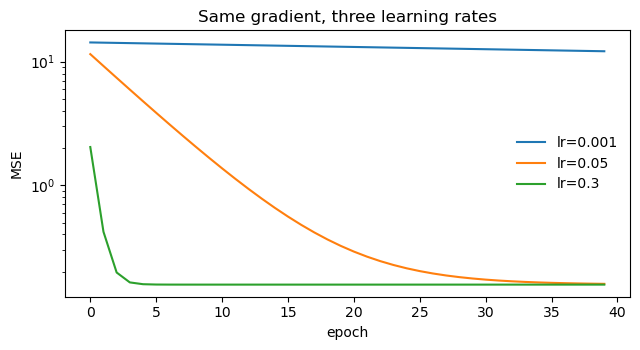

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for lr in [0.001, 0.05, 0.3]:
    _, hist = descend(lr)
    ax.plot(hist, label=f"lr={lr}")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_yscale("log")
ax.legend(frameon=False); ax.set_title("Same gradient, three learning rates")
plt.tight_layout(); plt.show()

## 3. Where a naive sigmoid breaks

HW 2 says `sigmoid` must be "numerically stable for large ±z", and the test traps
overflow warnings. Here is the failure it is trapping.

In [7]:
import warnings

def naive_sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.array([-1000.0, -50.0, 0.0, 50.0, 1000.0])

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    out = naive_sigmoid(z)
    print("output  ", out)
    print("warnings", [str(w.message) for w in caught])

output   [0.00000000e+00 1.92874985e-22 5.00000000e-01 1.00000000e+00
 1.00000000e+00]
warnings ['overflow encountered in exp']


`np.exp(1000)` overflows to `inf`, and `1/(1+inf)` is `0.0` — the *value* is
right, but the warning means you computed it by overflowing, and the same
pattern inside a loss returns `nan` instead. The fix is to avoid ever calling
`exp` on a large positive number; the two branches of the sigmoid are
algebraically equal, so you can pick whichever is safe for the sign of `z`.

Working that out is part of the assignment. What this cell gives you is the
**test**: your version should produce no warning and no `nan` on the array
above, and should still round-trip `sigmoid(0) == 0.5`.

## 4. The parts sklearn does for you

Part 3 of HW 2 is not from scratch — it asks for a `Pipeline` and
cross-validation. The point of the pipeline is that scaling is *learned on the
training fold only*, which is what makes the cross-validated score honest.

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# 60 samples, 2000 pure-noise features, random labels. There is NO signal here;
# an honest classifier should score about 0.5.
noise_rng = np.random.default_rng(1)
X_noise = noise_rng.normal(size=(60, 2000))
y_noise = noise_rng.integers(0, 2, 60)

# Leaky: pick the 20 features most correlated with y using ALL the data,
# and only then cross-validate.
leaked = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)
print("leaky  ", f"{cross_val_score(LogisticRegression(max_iter=2000), leaked, y_noise, cv=5).mean():.3f}")

# Honest: the selection happens inside the pipeline, so each fold selects using
# only its own training rows.
honest = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=2000))
print("honest ", f"{cross_val_score(honest, X_noise, y_noise, cv=5).mean():.3f}")

leaky   0.900
honest  0.467


**Ninety percent accuracy, on data containing nothing.** The selection step saw
every label, kept the twenty features that happened to correlate with them by
chance, and handed the classifier a problem that was already solved. The honest
pipeline reports 0.47 — which is the truth, because the truth is a coin flip.

This is why every transform that *learns something* — scaling, selection,
imputation, encoding — belongs inside the pipeline rather than in front of it.
The rule is not "scaling is dangerous"; it is that anything fitted on data the
fold has not earned the right to see will flatter the fold's score.

---

## Where to go next

- **HW 2** — point `grad_check` at your own `mse_loss` / `mse_gradient`, and at
  your `logistic_gradient`. If it fails, read the ratio before rewriting.
- **Reading, Sessions 8–10** — the derivations these functions come from.
- **Session 11** — why the honest number above is still not the final one.